# The rating, end to end

MovieLens 100K is 100000 ratings by 943 users on 1682 movies, gathered from September 1997 through April 1998. The grid has $943 \times 1682 = 1586126$ cells, so $1486126$ of them are empty. Empty is not zero.

The stars are 6110 ones, 11370 twos, 27145 threes, 34174 fours, and 21201 fives. They sum to 352986, and the mean is $176493/50000$.

The first stored row is user 196 giving *Kolya* 3 stars. User 1, a 24-year-old technician, rated 272 movies at a mean of $491/136$ and gave *Toy Story* 5. *Star Wars* averages $231/53$ over 583 ratings. User 405 has the longest row, 737 ratings.

The bias prediction is $\bar r_u + \bar r_i - \mu$. On the toy, that is 4 for U1 on Room and 1 for U3 on Gold. A single perfect neighbor moves U1's Room prediction from 4 to $14/3$.

Fit the means on `ua.base` only. That file sums to 319153 over 90570 ratings. On the 9430 ratings in `ua.test`, the errors are about 1.122 for the global mean, 1.043 for the user mean, 1.042 for the movie mean, and 0.992 for the bias formula.

The first hidden row is user 1 on *Angels and Insects*, actual 4. The bias fraction is $2477732497/723744870$, about 3.423. Movies 1582 and 1653 have no base rating, so they are predicted from the user mean alone.


In [2]:
# Locate the MovieLens tables beside this notebook, or under the course root.
from pathlib import Path

def data_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "15-Movie Recommendation" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "u.info").exists():
            return direct
    raise FileNotFoundError(name)

def read_lines(name):
    return data_path(name).read_text(encoding="latin-1").splitlines()

def read_ratings(name):
    rows = []
    for line in read_lines(name):
        if not line.strip():
            continue
        user, item, rating, stamp = line.split("\t")
        rows.append((int(user), int(item), int(rating), int(stamp)))
    return rows

ratings = read_ratings("u.data")
print(len(ratings), ratings[0])


100000 (196, 242, 3, 881250949)


In [3]:
# The file, the toy, the one hidden rating, and the four holdout errors.
import math
from fractions import Fraction
from collections import defaultdict
assert len(ratings) == 100000
assert sum(rating for _, _, rating, _ in ratings) == 352986
assert Fraction(352986, 100000) == Fraction(176493, 50000)
assert 943 * 1682 - 100000 == 1486126

known = [5, 3, 4, 2, 4, 1, 2]
assert Fraction(sum(known), 7) == 3
assert 4 + 3 - 3 == 4
assert Fraction(3, 2) + Fraction(5, 2) - 3 == 1
assert 4 + (4 - Fraction(10, 3)) == Fraction(14, 3)

base = read_ratings("ua.base")
test = read_ratings("ua.test")
mu = float(Fraction(sum(r for _, _, r, _ in base), len(base)))
by_user = defaultdict(list)
by_movie = defaultdict(list)
for user, item, rating, _ in base:
    by_user[user].append(rating)
    by_movie[item].append(rating)
user_mean = {user: sum(values) / len(values) for user, values in by_user.items()}
movie_mean = {item: sum(values) / len(values) for item, values in by_movie.items()}

def rmse(errors):
    return math.sqrt(sum(error * error for error in errors) / len(errors))

errors = {"global": [], "user": [], "movie": [], "bias": []}
for user, item, rating, _ in test:
    pred_user = user_mean[user]
    if item in movie_mean:
        pred_movie = movie_mean[item]
        pred_bias = pred_user + pred_movie - mu
    else:
        pred_movie = mu
        pred_bias = pred_user
    errors["global"].append(mu - rating)
    errors["user"].append(pred_user - rating)
    errors["movie"].append(pred_movie - rating)
    errors["bias"].append(pred_bias - rating)
scores = {name: rmse(values) for name, values in errors.items()}
print(scores)
prediction = Fraction(472, 131) + Fraction(204, 61) - Fraction(319153, 90570)
print(prediction, float(prediction), test[0])
assert abs(scores["global"] - 1.1220056790985578) < 1e-12
assert abs(scores["user"] - 1.0431349635957983) < 1e-12
assert abs(scores["movie"] - 1.0417647969439812) < 1e-12
assert abs(scores["bias"] - 0.9919037709981934) < 1e-12
assert prediction == Fraction(2477732497, 723744870)
assert test[0][:3] == (1, 20, 4)


{'global': 1.1220056790985578, 'user': 1.0431349635957983, 'movie': 1.0417647969439812, 'bias': 0.9919037709981934}
2477732497/723744870 3.4234888559555525 (1, 20, 4, 887431883)


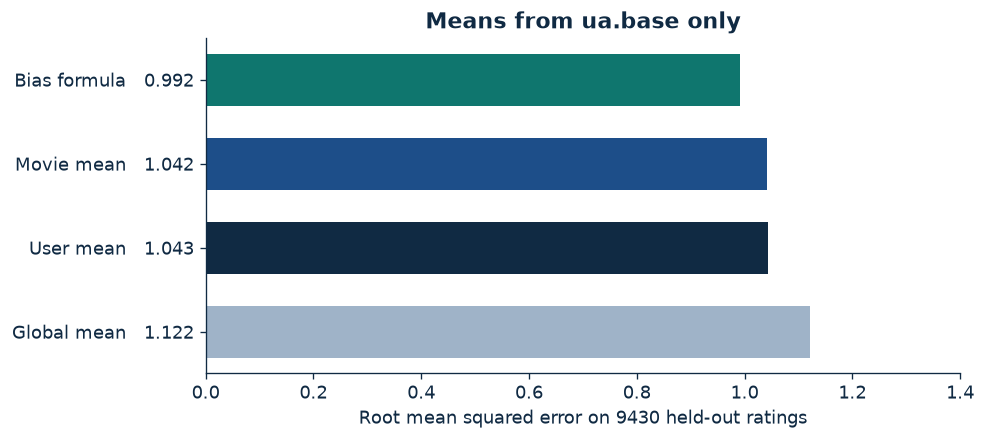

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# The same four holdout errors, from a global mean down to the bias formula.
labels = [
    "Global mean   1.122",
    "User mean   1.043",
    "Movie mean   1.042",
    "Bias formula   0.992",
]
scores = [1.1220056790985578, 1.0431349635957983, 1.0417647969439812, 0.9919037709981934]
colors = ["#9fb3c8", "#102a43", "#1d4e89", "#0f766e"]
figure, axis = plt.subplots(figsize=(8.4, 3.8))
positions = [0, 1, 2, 3]
axis.barh(positions, scores, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 1.4)
axis.set_xlabel("Root mean squared error on 9430 held-out ratings")
axis.set_title("Means from ua.base only")
figure.tight_layout()


## Pitfall

Restart and Run All rereads the tables. It does not fill *Angels and Insects* with 4 before computing the means. That 4 is the hidden rating. The prediction is about 3.423, and the 0.992 is the error over all 9430 hidden ratings.

## Summary

Mean star $176493/50000$. Bias formula $\bar r_u + \bar r_i - \mu$. On `ua.test`, RMSE about 0.992. One hidden case, user 1 on *Angels and Insects*, is the fraction $2477732497/723744870$ against a 4.
